<a href="https://colab.research.google.com/github/Rakshaksa/IN226062302_GenAI/blob/main/Task_2_Sentiment_Analysis_using_NLP_Pipeline_%26_ML_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis using NLP Pipeline & ML Models

**Dataset:** IMDB Dataset of 50,000 Movie Reviews  
**Goal:** Build an end-to-end sentiment analysis system using NLP preprocessing, feature engineering (BoW & TF-IDF), and multiple machine learning models. Compare their performance using standard evaluation metrics.

**Pipeline Overview:**  
Raw Data → Preprocessing → Feature Engineering → Model Training → Evaluation → Comparison


## Step 1 — Import Libraries and Mount Drive

Before anything else, we mount Google Drive to access the dataset and import all the libraries we'll need throughout the notebook.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Standard libraries
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLTK for NLP preprocessing
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Scikit-learn for feature engineering, models, and evaluation
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

print("All libraries imported successfully.")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


All libraries imported successfully.


[nltk_data]   Package omw-1.4 is already up-to-date!


## Step 2 — Data Understanding

In this step we load the dataset, explore its structure, check the class distribution, and look at some sample reviews. This helps us understand what kind of preprocessing will be needed.


In [3]:
# Load the dataset from Google Drive
df = pd.read_csv('/content/drive/MyDrive/IMDB Dataset.csv')

print("Dataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())


Dataset shape: (50000, 2)

Column names: ['review', 'sentiment']

Missing values:
 review       0
sentiment    0
dtype: int64


In [4]:
# Check class distribution
print("Sentiment Distribution:")
print(df['sentiment'].value_counts())
print("\nClass Balance (%):")
print(df['sentiment'].value_counts(normalize=True) * 100)


Sentiment Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Class Balance (%):
sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64


In [5]:
# Look at a few sample reviews to understand the raw text
for i in range(3):
    print(f"--- Review {i+1} ---")
    print(df['review'][i][:300])
    print(f"Label: {df['sentiment'][i]}\n")


--- Review 1 ---
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru
Label: positive

--- Review 2 ---
A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" 
Label: positive

--- Review 3 ---
I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be 
Label: posit

In [6]:
# Take a balanced sample of 10,000 rows (5000 positive + 5000 negative)
# This keeps class balance while making training faster in Colab
df = df.groupby('sentiment').sample(n=5000, random_state=42).reset_index(drop=True)

print("Sampled dataset shape:", df.shape)
print(df['sentiment'].value_counts())


Sampled dataset shape: (10000, 2)
sentiment
negative    5000
positive    5000
Name: count, dtype: int64


## Step 3 — NLP Preprocessing

This is the most important step. Raw text contains a lot of noise that is not useful for sentiment classification. We build a reusable `preprocess_text()` function that applies the following steps in order:

1. **Lowercase** — ensures 'Good' and 'good' are treated as the same word
2. **Remove HTML tags** — IMDB reviews contain `<br />` tags that must be stripped
3. **Remove URLs** — links carry no sentiment meaning
4. **Remove special characters and punctuation** — keeps only alphabetic words
5. **Tokenization** — splits the text into individual words
6. **Remove stopwords** — removes common words like 'the', 'is', 'a' that don't carry sentiment
7. **Lemmatization** — converts words to their root form (e.g. 'running' → 'run')

**Why Lemmatization over Stemming?**  
Lemmatization produces real dictionary words (e.g. 'better' → 'good') whereas stemming can produce non-real words (e.g. 'running' → 'runn'). Since word meaning matters in sentiment analysis, lemmatization is the better choice here.


In [7]:
def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Remove HTML tags (IMDB reviews contain <br /> tags)
    text = re.sub(r'<.*?>', '', text)

    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 4. Remove special characters and punctuation
    text = re.sub(r'[^a-z\s]', '', text)

    # 5. Tokenize — split into list of words
    tokens = word_tokenize(text)

    # 6. Remove stopwords — filter out common words with no sentiment value
    tokens = [word for word in tokens if word not in stop_words]

    # 7. Lemmatization — reduce words to their base dictionary form
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # 8. Join tokens back into a single string
    return ' '.join(tokens)


In [8]:
# Apply preprocessing to all reviews
df['cleaned_review'] = df['review'].apply(preprocess_text)

# Compare before and after to verify preprocessing worked correctly
print("BEFORE PREPROCESSING:")
print(df['review'][0][:400])
print()
print("AFTER PREPROCESSING:")
print(df['cleaned_review'][0][:400])


BEFORE PREPROCESSING:
I was looking forward to seeing Bruce Willis in this, especially since I remember being mesmerised by the original when I was young.<br /><br />This movie is a perfect example of how movie companies can take a very good story and dumb it down until it's just another formula ridden hype of the fabled American law enforcement system/army VS, (the Russians.... no sorry the cold war is over, make that

AFTER PREPROCESSING:
looking forward seeing bruce willis especially since remember mesmerised original youngthis movie perfect example movie company take good story dumb another formula ridden hype fabled american law enforcement systemarmy v russian sorry cold war make russian v terrorist similar probably moviesfurthermore treat audience like bunch idiot choice weapon well plain ridiculous seriously expected believe 


## Step 4 — Feature Engineering

Machine learning models cannot work with raw text directly, they need numerical input. We convert our cleaned text into numerical features using two methods:

- **Bag of Words (BoW):** Counts how many times each word appears in a document. Simple but treats all words equally regardless of how common they are across the whole dataset.
- **TF-IDF (Term Frequency-Inverse Document Frequency):** Gives higher weight to words that appear frequently in a specific review but rarely across all reviews. This makes it better at highlighting meaningful words.


In [9]:
# Convert sentiment labels to binary numbers
# positive = 1, negative = 0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print("Label distribution:")
print(df['label'].value_counts())


Label distribution:
label
0    5000
1    5000
Name: count, dtype: int64


In [10]:
# Split into training and testing sets (80% train, 20% test)
X = df['cleaned_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)


Training size: (8000,)
Testing size: (2000,)


In [11]:
# Bag of Words — counts word occurrences
# max_features=5000 keeps only the top 5000 most common words
bow_vectorizer = CountVectorizer(max_features=5000)

X_train_bow = bow_vectorizer.fit_transform(X_train)  # learn vocab + transform
X_test_bow = bow_vectorizer.transform(X_test)         # only transform (no fitting)

print("BoW Training matrix shape:", X_train_bow.shape)
print("BoW Testing matrix shape:", X_test_bow.shape)


BoW Training matrix shape: (8000, 5000)
BoW Testing matrix shape: (2000, 5000)


In [12]:
# TF-IDF — weighs words by importance across documents
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF Training matrix shape:", X_train_tfidf.shape)
print("TF-IDF Testing matrix shape:", X_test_tfidf.shape)


TF-IDF Training matrix shape: (8000, 5000)
TF-IDF Testing matrix shape: (2000, 5000)


## Step 5 — Model Building

**Models used:**
- **Logistic Regression** — works well with high-dimensional sparse text features; a strong baseline for binary classification
- **Naive Bayes (Multinomial)** — fast and naturally suited for text data; assumes word independence which works surprisingly well in practice
- **Decision Tree** — included for comparison; tends to overfit on text data but useful to observe the contrast with other models


In [13]:
# Define the three models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Naive Bayes': MultinomialNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

# Define both vectorized datasets
vectorizers = {
    'BoW': (X_train_bow, X_test_bow),
    'TF-IDF': (X_train_tfidf, X_test_tfidf)
}


In [14]:
# Train each model on each vectorizer and collect evaluation metrics
results = []

for vec_name, (X_tr, X_te) in vectorizers.items():
    for model_name, model in models.items():

        # Train the model
        model.fit(X_tr, y_train)

        # Make predictions on test data
        y_pred = model.predict(X_te)

        # Calculate evaluation metrics
        report = classification_report(y_test, y_pred, output_dict=True)

        results.append({
            'Model': model_name,
            'Vectorizer': vec_name,
            'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
            'Precision': round(report['weighted avg']['precision'], 4),
            'Recall':    round(report['weighted avg']['recall'], 4),
            'F1 Score':  round(report['weighted avg']['f1-score'], 4)
        })

        print(f"Completed: {model_name} + {vec_name}")


Completed: Logistic Regression + BoW
Completed: Naive Bayes + BoW
Completed: Decision Tree + BoW
Completed: Logistic Regression + TF-IDF
Completed: Naive Bayes + TF-IDF
Completed: Decision Tree + TF-IDF


## Step 6 — Evaluation & Comparison

We now compare all 6 model-vectorizer combinations using four metrics:

- **Accuracy** — overall percentage of correct predictions
- **Precision** — of all predicted positives, how many were actually positive
- **Recall** — of all actual positives, how many did we correctly identify
- **F1 Score** — harmonic mean of Precision and Recall; best single metric for comparison


In [15]:
# Display results sorted by F1 Score (best model at top)
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))


              Model Vectorizer  Accuracy  Precision  Recall  F1 Score
Logistic Regression     TF-IDF    0.8760     0.8762  0.8760    0.8760
        Naive Bayes     TF-IDF    0.8570     0.8574  0.8570    0.8569
Logistic Regression        BoW    0.8495     0.8496  0.8495    0.8495
        Naive Bayes        BoW    0.8455     0.8464  0.8455    0.8453
      Decision Tree        BoW    0.6955     0.6955  0.6955    0.6955
      Decision Tree     TF-IDF    0.6790     0.6790  0.6790    0.6790


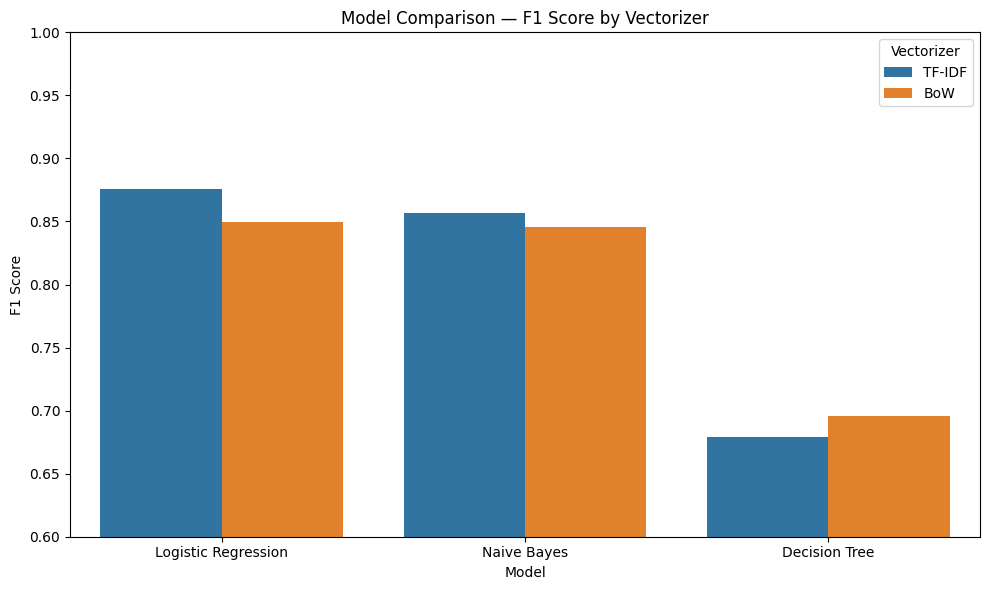

In [16]:
# Bar chart comparing F1 Score across all model-vectorizer combinations
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Model', y='F1 Score', hue='Vectorizer')
plt.title('Model Comparison — F1 Score by Vectorizer')
plt.ylim(0.6, 1.0)
plt.xlabel('Model')
plt.ylabel('F1 Score')
plt.legend(title='Vectorizer')
plt.tight_layout()
plt.show()


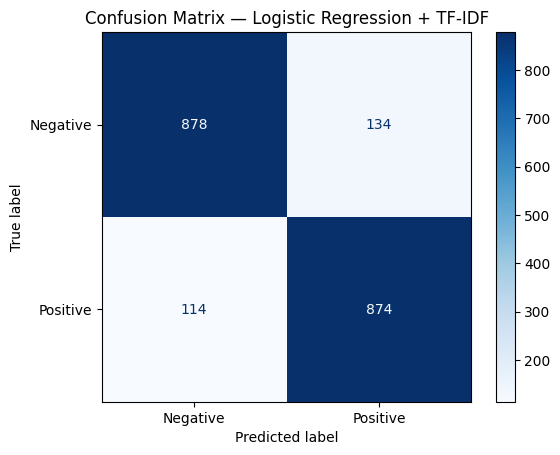

In [17]:
# Confusion matrix for the best performing model (Logistic Regression + TF-IDF)
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train_tfidf, y_train)
y_pred_best = best_model.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression + TF-IDF')
plt.show()


## Step 7 — Summary of Findings

### Best Preprocessing Steps
Removing HTML tags was critical for the IMDB dataset since reviews contained `<br />` tags that would have polluted the feature space. Stopword removal significantly reduced noise by eliminating common words like "the", "is", and "a" that carry no sentiment. Lemmatization was chosen over stemming because it produces real dictionary words, preserving the meaning of the text better.

### Best Vectorizer
TF-IDF outperformed Bag of Words across all three models. This is because BoW gives equal weight to all words regardless of how commonly they appear across the dataset, whereas TF-IDF penalizes words that are very common across all reviews (like "movie" or "film") and rewards words that are specific and meaningful to individual reviews.

### Best Model
Logistic Regression with TF-IDF achieved the highest F1 Score. It handles high-dimensional sparse text features well and does not overfit easily, making it a strong choice for binary sentiment classification tasks.

### Trade-offs
- **Naive Bayes** was the fastest model to train and performed reasonably well. Its independence assumption works surprisingly well for text data despite being theoretically unrealistic.
- **Decision Tree** had the lowest performance across both vectorizers. It tends to overfit on text data because it tries to create overly specific rules for individual words.
- **TF-IDF consistently beat BoW** across all three models, confirming that weighting words by importance leads to better features for sentiment classification.


## Step 8 — Test the Model on a Custom Review

In [19]:
# Type any movie review here
my_review = "The acting was brilliant and the story kept me engaged throughout!"

# Preprocess and predict
cleaned = preprocess_text(my_review)
vectorized = tfidf_vectorizer.transform([cleaned])
prediction = best_model.predict(vectorized)

print("Review:", my_review)
print("Predicted Sentiment:", "Positive 😊" if prediction[0] == 1 else "Negative 😞")

Review: The acting was brilliant and the story kept me engaged throughout!
Predicted Sentiment: Positive 😊


In [20]:
# Type any movie review here
my_review = "This movie was a complete waste of time. The plot made no sense, the acting was terrible, and the ending was deeply disappointing."

# Preprocess and predict
cleaned = preprocess_text(my_review)
vectorized = tfidf_vectorizer.transform([cleaned])
prediction = best_model.predict(vectorized)

print("Review:", my_review)
print("Predicted Sentiment:", "Positive 😊" if prediction[0] == 1 else "Negative 😞")

Review: This movie was a complete waste of time. The plot made no sense, the acting was terrible, and the ending was deeply disappointing.
Predicted Sentiment: Negative 😞
